In [1]:
from google.colab import drive

drive.mount('/content/drive')

# 認証が完了すると、「drive/My Drive」以下にgoogle driveのルートがマウントされる。

Mounted at /content/drive


In [ ]:
# import pandas as pd
# from pathlib import Path

# file_path = Path("/content/drive/MyDrive/Data/japan-inbound-tourism-time-series/jnto_monthly_visitor_arrivals_2003_2026.xlsx")
# output_dir = Path("/content/drive/MyDrive/Data/japan-inbound-tourism-time-series/outputs/")

# output_dir.mkdir(parents=True, exist_ok=True)

# # Excelブックを開く
# xls = pd.ExcelFile(file_path)

# DataFrame化・CSV保存

In [ ]:
# records = []

# for sheet in xls.sheet_names:
#     year = int(sheet)

#     df = pd.read_excel(file_path, sheet_name=sheet, header=None)
#     header_row = df.iloc[3]

#     total_row_idx = df[df.iloc[:, 0] == "総数"].index[0]
#     total_row = df.iloc[total_row_idx]

#     for col in range(len(header_row)):
#         month_label = header_row[col]
#         value = total_row[col]

#         if pd.notna(month_label) and isinstance(month_label, str) and month_label.endswith("月"):
#             month = int(month_label.replace("月", "").strip())

#             if pd.notna(value):
#                 value_clean = str(value).replace(",", "").strip()
#                 records.append({
#                     "date": pd.Timestamp(year=year, month=month, day=1),
#                     "visitor_arrivals": int(float(value_clean))
#                 })

# ts_df = pd.DataFrame(records).sort_values("date").reset_index(drop=True)

# output_path = output_dir / "monthly_visitor_arrivals_total.csv"
# ts_df.to_csv(output_path, index=False, encoding="utf-8-sig")

# print(ts_df.head())
# print(ts_df.tail())
# print(ts_df.shape)
# print(f"Saved to: {output_path}")

        date  visitor_arrivals
0 2003-01-01            450847
1 2003-02-01            394869
2 2003-03-01            456614
3 2003-04-01            354054
4 2003-05-01            288562
          date  visitor_arrivals
273 2025-10-01           3896524
274 2025-11-01           3518195
275 2025-12-01           3617791
276 2026-01-01           3597500
277 2026-02-01           3466700
(278, 2)
Saved to: /content/drive/MyDrive/Data/japan-inbound-tourism-time-series/outputs/monthly_visitor_arrivals_total.csv


# CSV

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Google Drive path (for Colab)
df = pd.read_csv("/content/drive/MyDrive/Data/japan-inbound-tourism-time-series/outputs/monthly_visitor_arrivals_total.csv")
# file_path = Path("data/processed/monthly_visitor_arrivals_total.csv") # for GitHub execution

# datetime64[ns]
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")

df.head()

,visitor_arrivals
date,
2003-01-01,450847
2003-02-01,394869
2003-03-01,456614
2003-04-01,354054
2003-05-01,288562


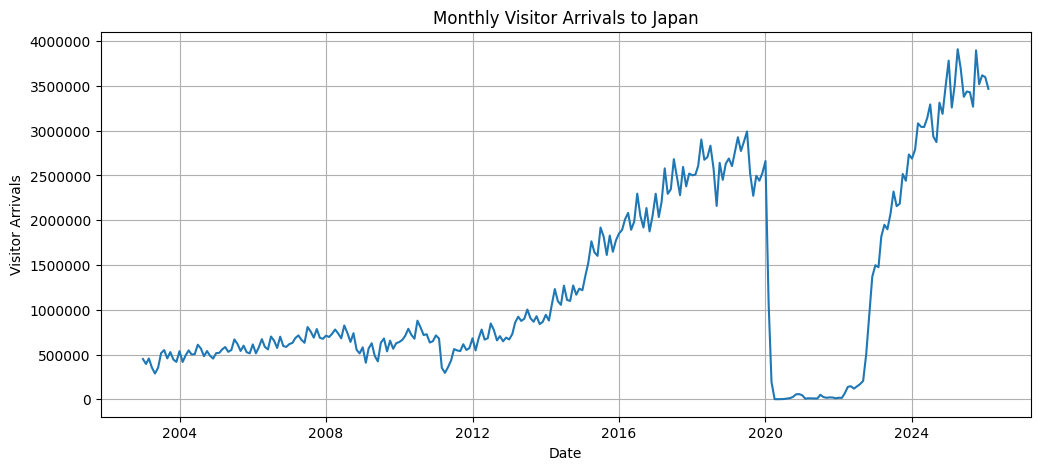

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["visitor_arrivals"])
plt.title("Monthly Visitor Arrivals to Japan")
plt.xlabel("Date")
plt.ylabel("Visitor Arrivals")
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

# データ分割

In [13]:
train = df[df.index < "2019-01-01"]
test = df[df.index >= "2019-01-01"]

print(train.shape, test.shape)
print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

(192, 1) (86, 1)
2003-01-01 00:00:00 2018-12-01 00:00:00
2019-01-01 00:00:00 2026-02-01 00:00:00


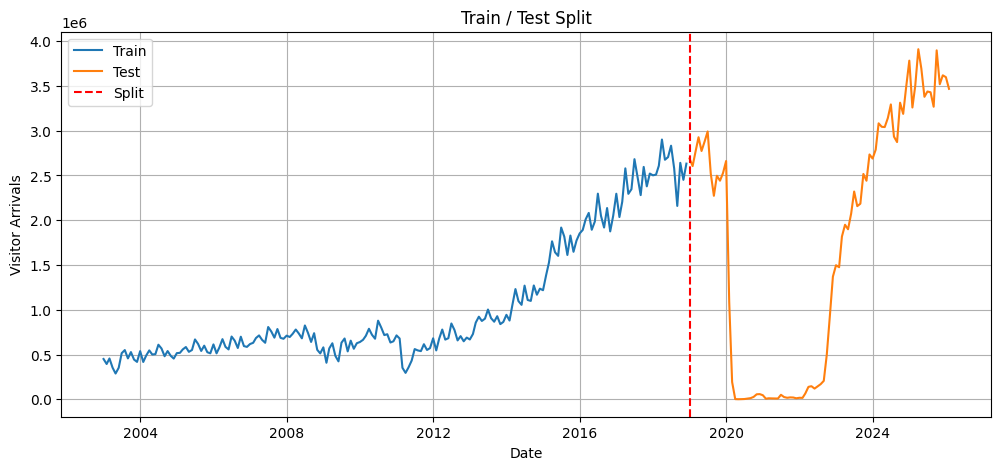

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train["visitor_arrivals"], label="Train")
plt.plot(test.index, test["visitor_arrivals"], label="Test")
plt.axvline(pd.to_datetime("2019-01-01"), color="red", linestyle="--", label="Split")
plt.title("Train / Test Split")
plt.xlabel("Date")
plt.ylabel("Visitor Arrivals")
plt.legend()
plt.grid(True)
plt.show()

# SARIMA（実装）

In [15]:
!pip install statsmodels

In [16]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train["visitor_arrivals"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

print(results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                   visitor_arrivals   No. Observations:                  192
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -2110.469
Date:                            Sun, 29 Mar 2026   AIC                           4230.939
Time:                                    09:04:26   BIC                           4246.469
Sample:                                01-01-2003   HQIC                          4237.243
                                     - 12-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2942      0.283      1.038      0.299      -0.261       0.850
ma.L1         -0.5510      0.261   

In [18]:
forecast = results.get_forecast(steps=len(test))

# 予測の中心値（モデルが「たぶんこのくらい」と考えた予測値）
pred_mean = forecast.predicted_mean

# 予測区間（だいたいこの範囲に収まりそう）
pred_ci = forecast.conf_int()

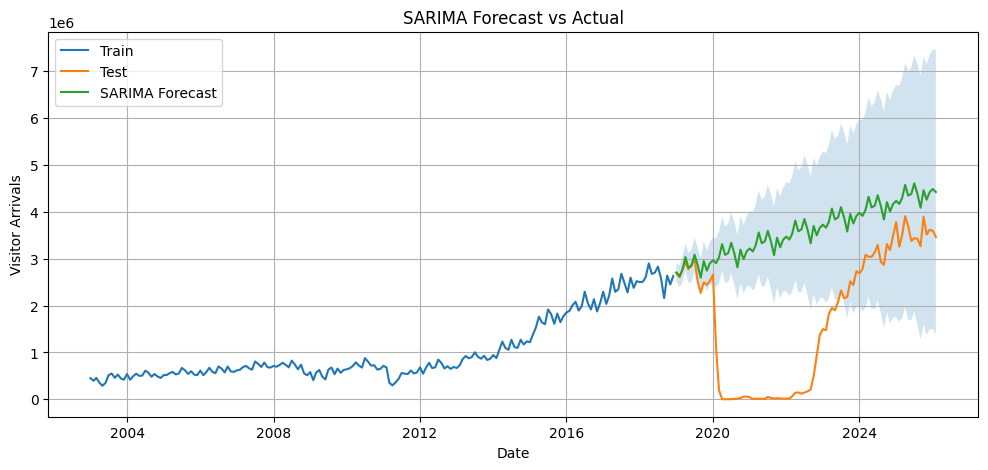

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(train.index, train["visitor_arrivals"], label="Train")
plt.plot(test.index, test["visitor_arrivals"], label="Test")
plt.plot(test.index, pred_mean, label="SARIMA Forecast")

plt.fill_between(
    test.index,
    pred_ci.iloc[:, 0],
    pred_ci.iloc[:, 1],
    alpha=0.2
)

plt.title("SARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Visitor Arrivals")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test["visitor_arrivals"], pred_mean)
rmse = np.sqrt(mean_squared_error(test["visitor_arrivals"], pred_mean))

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 1847598.9937262577
RMSE: 2218194.638514397
